In [30]:
"""
Parte 1.

    Selecciona o crea un archivo CSV (puede ser de clientes, ventas, productos, etc.).
        Puedes generarlo manualmente o descargar uno sencillo.
    Utilizando Pandas, realiza lo siguiente:

    Cargar el archivo:"""

import pandas as pd
from IPython.display import display

def cargar_dataframe():
    url = "https://raw.githubusercontent.com/aldairmh98/maestria/master/actividad_6/Chocolate_Sales.csv"
    df = pd.read_csv(url)
    return df

def leer_primeros(df):
    #Mostrar las primeras filas:
    display(df.head())

def show_metadata(df):
    """Identificar: número de filas y columnas"""
    """tipos de datos"""
    """valores nulos"""
    display(df.info())

In [31]:
"""Parte 2.

    Realiza al menos dos de las siguientes acciones:

    Eliminar valores nulos
    Rellenar datos faltantes
    Filtrar registros (por ejemplo: mayores a cierta edad)
    Crear una nueva columna (por ejemplo: clasificación)
    Convertir tipos de datos"""
def preprocess_data(df):
    #Rellenar datos faltantes de Order_date
    df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].mode()[0])
    #Crear nueva columna
    df['Price_Pre_Discount'] = (df['Price_per_Box'] * 100)/ (100 - df['Discount_Pct'])
    #Eliminando cajas no entregadas
    df = df[df['Boxes_Shipped'] > 0]
    #Transformando Amount a numeric
    df['Amount'] = df['Amount'].astype(str).str.replace('$', '', regex=False)
    df['Amount'] = df['Amount'].str.replace(',', '', regex=False)
    df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

    display(df.info())
    return df



In [32]:
"""Parte 3.

    Utiliza Pandas para:

    Obtener estadísticas básicas: df.describe()

    Realizar al menos un análisis, por ejemplo:
        promedio
        conteo por categoría
        agrupación (groupby)"""

def show_stats(df):
    display(df.describe())
    #Promedio de marketing gastado por País
    display(df.groupby('Country')[['Marketing_Spend', 'Boxes_Shipped']].mean())
    display(df.groupby('Country')['Boxes_Shipped'].count())


In [33]:
"""Parte 4.

    Utiliza Matplotlib o Seaborn para crear al menos dos gráficos:

    Gráfica de barras
    Histograma o dispersión

Ejemplo:
"""
import matplotlib.pyplot as plt

def show_plots(df):
    df.groupby('Country')['Boxes_Shipped'].count().plot(kind='bar')
    plt.show()
    df.groupby('Country')[['Marketing_Spend', 'Amount']].mean().plot(kind='bar')
    plt.show()


,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  str    
 1   Product          200000 non-null  str    
 2   Country          200000 non-null  str    
 3   Channel          200000 non-null  str    
 4   Salesperson      200000 non-null  str    
 5   Order_Date       199563 non-null  str    
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 16.8 MB


None

<class 'pandas.DataFrame'>
Index: 198044 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order_ID            198044 non-null  str    
 1   Product             198044 non-null  str    
 2   Country             198044 non-null  str    
 3   Channel             198044 non-null  str    
 4   Salesperson         198044 non-null  str    
 5   Order_Date          198044 non-null  str    
 6   Discount_Pct        197560 non-null  float64
 7   Price_per_Box       197590 non-null  float64
 8   Marketing_Spend     197589 non-null  float64
 9   Boxes_Shipped       198044 non-null  int64  
 10  Amount              198044 non-null  float64
 11  Price_Pre_Discount  197153 non-null  float64
dtypes: float64(5), int64(1), str(6)
memory usage: 19.6 MB


None

,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Price_Pre_Discount
count,199511.000000,199543.000000,199539.000000,200000.000000,199101.000000
mean,13.107457,5.911507,95.450141,139.584105,6.828271
std,6.374477,4.954976,66.243760,118.665393,5.736154
min,0.000000,2.040000,4.300000,-1642.000000,2.060606
25%,8.300000,2.950000,52.270000,67.000000,3.394018
50%,12.600000,3.280000,78.850000,113.000000,3.797468
75%,17.500000,4.570000,118.710000,180.000000,5.521558
max,38.300000,21.650000,798.222443,3811.000000,29.052632


,Marketing_Spend,Boxes_Shipped
Country,,
Australia,95.321838,124.366309
Brazil,95.726941,188.835876
Germany,95.284917,122.572005
India,95.534584,100.462487
Japan,95.442972,132.361056


Country
Australia    92594
Brazil       52960
Germany      25269
India        17514
Japan        11663
Name: Boxes_Shipped, dtype: int64

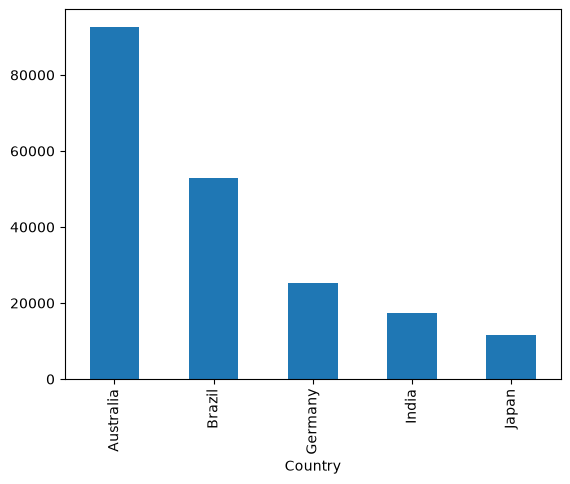

TypeError: dtype 'str' does not support operation 'mean'

In [ ]:
df = cargar_dataframe()
leer_primeros(df)
show_metadata(df)
df = preprocess_data(df)
show_stats(df)
show_plots(df)